[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mohammedhemed77/Transformers-through-Hemed-lens/blob/main/transformers_1.ipynb.ipynb)

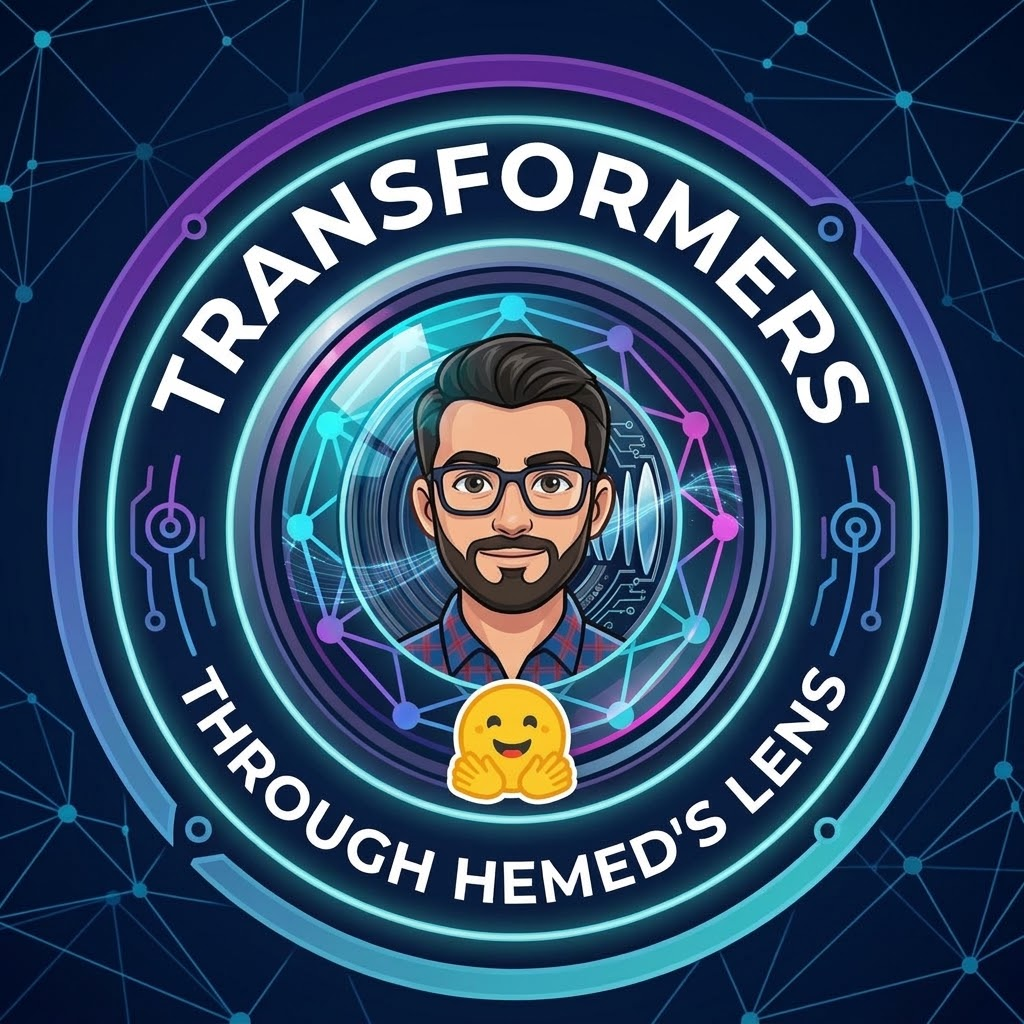

In [13]:
logo = '/content/drive/MyDrive/logo_modest.jpg'
from IPython.display import Image, display
# Adjust width in pixels
display(Image(filename=logo, width=400))

#### Just in few lines of code use transformers

#### Setup

In [2]:
!pip install transformers[sentencepiece]


### Go to hugging face and choose model

In [3]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, AutoConfig

model_id = "NAMAA-Space/masrawy-english-to-egyptian-arabic-translator-v2.9"

# Load as Seq2Seq (Encoder-Decoder)
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSeq2SeqLM.from_pretrained(model_id).to("cuda" if torch.cuda.is_available() else "cpu")

# Input text as standard string
text = "Abdelrahman loves hanan and hanan is engaged :D "

# Tokenize and Generate
inputs = tokenizer(text, return_tensors="pt").to(model.device)
translated_tokens = model.generate(**inputs, max_new_tokens=100)

config = AutoConfig.from_pretrained(model_id)
print(config)

# Decode output
translation = tokenizer.batch_decode(translated_tokens, skip_special_tokens=True)[0]
print("Translation:", translation)

config.json:   0%|          | 0.00/1.13k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/824 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/806k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/916k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.21M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

[transformers] Both `max_new_tokens` (=100) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


MarianConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "architectures": [
    "MarianMTModel"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder_layerdrop": 0.0,
  "decoder_layers": 6,
  "decoder_start_token_id": 61246,
  "decoder_vocab_size": 61247,
  "dropout": 0.1,
  "dtype": "float32",
  "encoder_attention_heads": 16,
  "encoder_ffn_dim": 4096,
  "encoder_layerdrop": 0.0,
  "encoder_layers": 6,
  "eos_token_id": 25897,
  "forced_eos_token_id": 25897,
  "init_std": 0.02,
  "is_decoder": false,
  "is_encoder_decoder": true,
  "max_position_embeddings": 1024,
  "model_type": "marian",
  "normalize_embedding": false,
  "pad_token_id": 61246,
  "scale_embedding": true,
  "share_encoder_decoder_embeddings": true,
  "static_position_embeddings": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.16.1",
  "use_cache": true,
  "voca

### Classification Task

In [4]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")
classifier ("you are bad person !")


[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'NEGATIVE', 'score': 0.999601423740387}]

## **Steps from intput text to output labels**

####1- choose the target model and specific checkpoint name


In [5]:
from transformers import AutoTokenizer

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

####2-convert input text to numbers via tokenizer

In [6]:
raw_inputs = [
    "I've been waiting for a HuggingFace course my whole life.",
    "I hate this so much!",
]
inputs = tokenizer(raw_inputs, padding=True, truncation=True, return_tensors="pt")
print(inputs)

{'input_ids': tensor([[  101,  1045,  1005,  2310,  2042,  3403,  2005,  1037, 17662, 12172,
          2607,  2026,  2878,  2166,  1012,   102],
        [  101,  1045,  5223,  2023,  2061,  2172,   999,   102,     0,     0,
             0,     0,     0,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]])}


####3: Load the Model Checkpoint

In [7]:
# You can donwload the model using AutoModel class
from transformers import AutoModel

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
model = AutoModel.from_pretrained(checkpoint)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased-finetuned-sst-2-english
Key                   | Status     |  | 
----------------------+------------+--+-
classifier.bias       | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 
pre_classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
from transformers import AutoModelForSequenceClassification

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
outputs = model(**inputs)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

####4-Step 4: Pass Inputs to the Model (Forward Pass)

In [9]:
import torch

outputs = model(**inputs)

# Pass the tokenized batch to the model
outputs = model(**inputs)

# The model returns raw, unnormalized scores (logits)
print(outputs.logits)
print('\n' ,outputs.logits.shape)

tensor([[-1.5607,  1.6123],
        [ 4.1692, -3.3464]], grad_fn=<AddmmBackward0>)

 torch.Size([2, 2])


####5-Convert Logits to Probabilities : Apply the Softmax function to convert raw logits into normalized probabilities that sum to $1.0$

In [10]:
# Apply Softmax along the last dimension (dim=-1)
predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
print(predictions)

tensor([[4.0195e-02, 9.5980e-01],
        [9.9946e-01, 5.4418e-04]], grad_fn=<SoftmaxBackward0>)


####6- postprocess predictions into human readable text

In [11]:
model.config.id2label

{0: 'NEGATIVE', 1: 'POSITIVE'}

In [12]:
probs = torch.softmax(predictions, dim=-1)
class_ids = torch.argmax(predictions, dim=-1).tolist()

for text, class_id, prob in zip(raw_inputs, class_ids, probs):
    label = model.config.id2label[class_id]
    confidence = prob[class_id].item()

    print(f"Text:       '{text}'")
    print(f"Prediction: {label} ({confidence:.2%})\n")

Text:       'I've been waiting for a HuggingFace course my whole life.'
Prediction: POSITIVE (71.50%)

Text:       'I hate this so much!'
Prediction: NEGATIVE (73.08%)

